<a href="https://colab.research.google.com/github/giankev/lightweight-model-for-signal-processing/blob/main/dataset_comunication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install sionna tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.4/520.4 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.4 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextens

In [53]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Any, Optional
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

import sionna
from sionna.phy.mapping import Constellation, Mapper, Demapper
from sionna.phy.channel import AWGN
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

# Sionna global RNG seed (for AWGN reproducibility)
try:
    from sionna.phy import config as sn_config
except Exception:
    sn_config = None


# =============================================================================
# Config
# =============================================================================
@dataclass(frozen=True)
class SimConfig:
    """
    Single-carrier symbol-rate generator: 16-QAM + LDPC + pilots + (CFO-like ramp + AWGN).

    Per-sample (aka per-frame) model:
      x_tx = [pilots(P), data(L)]  -> total T=P+L symbols
      y[t] = x_tx[t] * exp(j*(phi0 + 2*pi*cfo_norm*t)) + w_awgn[t]

    Notes:
      - "cfo_norm" here is normalized CFO in cycles/symbol (your previous "cto_norm").
        Phase increment per symbol = 2*pi*cfo_norm.
      - Eb/N0 is defined w.r.t. information bits; pilot overhead accounted via (P+L)/L.
    """

    # Dataset size (N samples/frames)
    num_examples: int = 10_000

    # Modulation
    seq_length: int = 128            # L data symbols
    bits_per_symbol: int = 4         # m=4 -> 16-QAM

    # LDPC (5G)
    k: int = 256                     # info bits per sample; coded bits n=L*m

    # Pilots
    pilot_len: int = 16              # P pilot symbols
    pilot_seed: int = 999            # deterministic pilot bits

    # Channel: Eb/N0 range (info-bit)
    ebn0_db_min: float = 0.0
    ebn0_db_max: float = 10.0

    # Impairments ranges
    phase_min: float = -np.pi
    phase_max: float = np.pi
    cfo_norm_min: float = -0.002     # cycles/symbol
    cfo_norm_max: float = 0.002

    # Receiver blocks
    demap_method: str = "app"        # "app" or "maxlog"
    dec_num_iter: int = 20
    cn_update: str = "minsum"

    # Reproducibility (controls TF generator + Sionna global RNG)
    seed: int = 46
    seed_noise: Optional[int] = None  # AWGN; None ->  seed
    llr_noise_scaling: float = 1.0    # alpha >= 1 LLR (vedi)

    # Format
    channels_last: bool = True       # IQ format: [N,T,2] if True else [N,2,T]
    tf_rdtype: tf.dtypes.DType = tf.float32
    tf_cdtype: tf.dtypes.DType = tf.complex64


# =============================================================================
# Helpers
# =============================================================================
def set_global_seed(seed: int, seed_sionna: Optional[int] = None) -> None:
    """Best-effort reproducibility across TF + Sionna internal RNG + numpy."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    if sn_config is not None and seed_sionna is not None:
        sn_config.seed = int(seed_sionna)

def complex_to_2ch_real(x: tf.Tensor, channels_last: bool) -> tf.Tensor:
    """Convert complex [...,T] -> real IQ [...,T,2] or [...,2,T]."""
    i = tf.math.real(x)
    q = tf.math.imag(x)
    return tf.stack([i, q], axis=-1 if channels_last else -2)


def expj(theta: tf.Tensor, cdtype: tf.DType) -> tf.Tensor:
    """exp(j*theta) with complex dtype."""
    return tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)


def build_sionna_blocks(cfg: SimConfig):
    """Create modulation/coding/channel blocks."""
    m = cfg.bits_per_symbol
    constellation = Constellation("qam", num_bits_per_symbol=m)
    mapper = Mapper(constellation=constellation)
    demapper = Demapper(cfg.demap_method, constellation=constellation)
    awgn = AWGN()
    n = cfg.seq_length * cfg.bits_per_symbol
    encoder = LDPC5GEncoder(k=cfg.k, n=n, num_bits_per_symbol=m)
    decoder = LDPC5GDecoder(
        encoder=encoder,
        num_iter=cfg.dec_num_iter,
        return_infobits=True,
        hard_out=True,
        cn_update=cfg.cn_update,
    )
    return constellation, mapper, demapper, awgn, encoder, decoder


def make_deterministic_pilots_tf(cfg: SimConfig, N: int, mapper: Mapper) -> Dict[str, tf.Tensor]:
    """Create deterministic pilot bits and symbols (same for all samples)."""
    pilot_rng = tf.random.Generator.from_seed(cfg.pilot_seed)
    P = cfg.pilot_len
    m = cfg.bits_per_symbol
    pilot_bits = pilot_rng.uniform([P * m], minval=0, maxval=2, dtype=tf.int32)   # [P*m]
    x_pilot_1 = tf.cast(mapper(tf.reshape(pilot_bits, [1, P * m])), cfg.tf_cdtype)  # [1,P]
    x_pilot = tf.tile(x_pilot_1, [N, 1])  # [N,P]
    return {"pilot_bits": pilot_bits, "x_pilot": x_pilot}


# =============================================================================
# TX + Channel (single source of truth)
# =============================================================================
def simulate_full_frames_tf(cfg: SimConfig) -> Dict[str, Any]:
    """
    Generate N full frames (each frame = pilots+data) in TF tensors.

    Returns TF tensors:
      - info_bits:  [N,k] int32
      - coded_bits: [N,n] int32
      - pilot_bits: [P*m] int32
      - x_pilot:    [N,P] complex
      - x_data:     [N,L] complex
      - x_tx:       [N,T] complex
      - y_rx:       [N,T] complex
      - phi0:       [N,1] float
      - cfo_norm:   [N,1] float   (cycles/symbol)
      - ebn0_db:    [N]   float
      - no:         [N,1] float   (complex noise variance)
      - meta: dict
    """
    set_global_seed(cfg.seed)
    rng = tf.random.Generator.from_seed(cfg.seed)

    N = cfg.num_examples
    L = cfg.seq_length
    m = cfg.bits_per_symbol
    P = cfg.pilot_len
    T = P + L
    n = L * m
    k = cfg.k

    if not (0 < k < n):
        raise ValueError(f"Invalid k={k}. Must satisfy 0 < k < n={n} (n=L*m).")
    R = float(k) / float(n)

    _, mapper, _, awgn, encoder, _ = build_sionna_blocks(cfg)

    # Pilots (deterministic)
    pilot_pack = make_deterministic_pilots_tf(cfg, N, mapper)
    pilot_bits = pilot_pack["pilot_bits"]   # [P*m]
    x_pilot = pilot_pack["x_pilot"]         # [N,P]

    # Info bits + LDPC encode
    info_bits = rng.uniform([N, k], minval=0, maxval=2, dtype=tf.int32)  # [N,k]
    coded_bits_f = encoder(tf.cast(info_bits, cfg.tf_rdtype))            # float {0,1} [N,n]
    coded_bits = tf.cast(coded_bits_f, tf.int32)                         # int {0,1}  [N,n]

    # Map coded bits -> QAM symbols
    x_data = tf.cast(mapper(coded_bits), cfg.tf_cdtype)                  # [N,L]
    x_tx = tf.concat([x_pilot, x_data], axis=1)                          # [N,T]

    # Impairments: phase + CFO-like ramp
    phi0 = rng.uniform([N, 1], minval=cfg.phase_min, maxval=cfg.phase_max, dtype=cfg.tf_rdtype)  # [N,1]
    cfo = rng.uniform([N, 1], minval=cfg.cfo_norm_min, maxval=cfg.cfo_norm_max, dtype=cfg.tf_rdtype)  # [N,1]
    t = tf.range(T, dtype=cfg.tf_rdtype)[None, :]                        # [1,T]
    phi_total = phi0 + tf.constant(2.0 * np.pi, cfg.tf_rdtype) * cfo * t  # [N,T]
    x_tx_phase = x_tx * expj(phi_total, cfg.tf_cdtype)                   # [N,T]

    # Eb/N0 -> complex noise variance, include pilot overhead
    ebn0_db = rng.uniform([N], minval=cfg.ebn0_db_min, maxval=cfg.ebn0_db_max, dtype=cfg.tf_rdtype)  # [N]
    ebn0_lin = tf.pow(tf.constant(10.0, cfg.tf_rdtype), ebn0_db / 10.0)
    overhead = tf.constant((P + L) / L, dtype=cfg.tf_rdtype)
    es = tf.reduce_mean(tf.abs(x_tx_phase) ** 2, axis=1, keepdims=True)  # [N,1]
    no = es / (tf.reshape(ebn0_lin, [-1, 1]) * (m * R)) * overhead       # [N,1]

    # AWGN
    y_rx = tf.cast(awgn(x_tx_phase, no), cfg.tf_cdtype)                  # [N,T]

    return {
        "info_bits": info_bits,
        "coded_bits": coded_bits,
        "pilot_bits": pilot_bits,
        "x_pilot": x_pilot,
        "x_data": x_data,
        "x_tx": x_tx,
        "y_rx": y_rx,
        "phi0": phi0,
        "cfo_norm": cfo,
        "ebn0_db": ebn0_db,
        "no": no,
        "meta": {
            "N": int(N), "L": int(L), "P": int(P), "T": int(T),
            "m": int(m), "k": int(k), "n": int(n), "R": float(R),
            "seed": int(cfg.seed), "pilot_seed": int(cfg.pilot_seed),
            "demap_method": str(cfg.demap_method), "dec_num_iter": int(cfg.dec_num_iter),
            "cn_update": str(cfg.cn_update),
            "channels_last": bool(cfg.channels_last),
            "sionna_version": getattr(sionna, "__version__", "unknown"),
            "channel": "single-carrier; phi0 + CFO-like ramp + AWGN",
            "ebn0_note": "Eb/N0 w.r.t info bits; pilot overhead via (P+L)/L",
            "cfo_note": "cfo_norm in cycles/symbol; Δphi per symbol = 2*pi*cfo_norm",
            "cfo_range": [float(cfg.cfo_norm_min), float(cfg.cfo_norm_max)],
        }
    }


# =============================================================================
# Offline dataset (numpy) - save EVERYTHING useful
# =============================================================================
def generate_dataset_offline(cfg: SimConfig):
    """
    Generate full dataset offline (numpy arrays) for PyTorch.

    It stores BOTH:
      - Full-frame TX/RX IQ: pilots+data (so you can do pilot-aided CFO/CPE or end-to-end)
      - Convenient splits: pilot-only and data-only
      - Bits (info + coded), ebn0_db, no, true phi0/cfo_norm

    Keys are numpy arrays ready for torch.tensor(...) conversion.
    """
    full = simulate_full_frames_tf(cfg)

    N = full["meta"]["N"]
    P = full["meta"]["P"]
    T = full["meta"]["T"]

    # Full-frame IQ
    tx_iq_full = complex_to_2ch_real(full["x_tx"], cfg.channels_last).numpy().astype(np.float32)  # [N,T,2]
    rx_iq_full = complex_to_2ch_real(full["y_rx"], cfg.channels_last).numpy().astype(np.float32)  # [N,T,2]

    # Splits (views in numpy after slicing)
    if cfg.channels_last:
        tx_iq_pilot = tx_iq_full[:, :P, :]   # [N,P,2]
        tx_iq_data  = tx_iq_full[:, P:, :]   # [N,L,2]
        rx_iq_pilot = rx_iq_full[:, :P, :]
        rx_iq_data  = rx_iq_full[:, P:, :]
    else:
        # [N,2,T]
        tx_iq_pilot = tx_iq_full[:, :, :P]
        tx_iq_data  = tx_iq_full[:, :, P:]
        rx_iq_pilot = rx_iq_full[:, :, :P]
        rx_iq_data  = rx_iq_full[:, :, P:]

    ds = {
        # Labels
        "info_bits": full["info_bits"].numpy().astype(np.uint8),       # [N,k]
        "coded_bits": full["coded_bits"].numpy().astype(np.uint8),     # [N,n]
        "pilot_bits": full["pilot_bits"].numpy().astype(np.uint8),     # [P*m]

        # Signals (IQ)
        "tx_iq_full": tx_iq_full,          # [N,T,2] or [N,2,T]
        "rx_iq_full": rx_iq_full,          # [N,T,2] or [N,2,T]
        "tx_iq_pilot": tx_iq_pilot,        # [N,P,2] or [N,2,P]
        "rx_iq_pilot": rx_iq_pilot,
        "tx_iq_data": tx_iq_data,          # [N,L,2] or [N,2,L]
        "rx_iq_data": rx_iq_data,

        # Channel params / conditioning
        "phi0": full["phi0"].numpy().astype(np.float32),               # [N,1]
        "cfo_norm": full["cfo_norm"].numpy().astype(np.float32),       # [N,1]
        "ebn0_db": full["ebn0_db"].numpy().astype(np.float32),         # [N]
        "no": full["no"].numpy().astype(np.float32),                   # [N,1]

        "meta": full["meta"],
    }

    return ds

In [68]:
# =============================================================================
# Classical receivers (operate on TF full frames)
# =============================================================================
'''def classical_receiver(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
 """CPE-only: estimate one constant phase from pilots, derotate, demap, LDPC decode."""
  _, _, demapper, _, _, decoder = build_sionna_blocks(cfg)
   P = full["meta"]["P"]
   y_rx = full["y_rx"] # [N,T] complex
   x_pilot = full["x_pilot"] # [N,P] complex
    no = full["no"] # [N,1]
    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
     info_bits = tf.cast(full["info_bits"], tf.uint8)
      y_pilot = y_rx[:, :P] z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot), axis=1, keepdims=True) # [N,1]
      phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype) # [N,1]
      y_corr = y_rx * expj(-phi_hat, cfg.tf_cdtype) # [N,T]
       y_data_corr = y_corr[:, P:] # [N,L]
       llr = tf.cast(demapper(y_data_corr, no), cfg.tf_rdtype) # [N,n]
        hard_coded = tf.cast(llr > 0.0, tf.uint8)
        info_hat_f = decoder(llr)
        info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)
         ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
          ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
          bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))
           return {
             "phi_hat": phi_hat,
              "llr": llr,
              "info_bits_hat": info_hat,
               "metrics":
               { "ber_pre_coded": float(ber_pre.numpy()), "ber_post_info": float(ber_post.numpy()), "bler_post_info": float(bler_post.numpy()), } }'''

def estimate_phi_cfo_ml_grid(cfg,
                             y_pilot: tf.Tensor,  # [N,P] complex
                             x_pilot: tf.Tensor,  # [N,P] complex
                             grid_size: int = 129):
    """
    ML-like CFO/phase estimation over pilots via grid search in a known CFO range.

    Steps:
      1) Form normalized phasors r[p] = y[p] * conj(x[p]) / (|x[p]|^2 + eps)
         This removes pilot amplitude variations (important if pilots are 16-QAM).
      2) For each CFO candidate f in [cfo_min, cfo_max], compute
           z(f) = sum_p r[p] * exp(-j*2*pi*f*p)
         Under the model, z(f) is maximized in magnitude near the true CFO.
      3) Pick f_hat = argmax_f |z(f)|, and phi_hat = angle(z(f_hat)).

    Returns:
      phi_hat : [N,1] float (rad)
      cfo_hat : [N,1] float (cycles/symbol)
      conf    : [N,1] float (0..1), normalized peak magnitude indicator
    """
    rdtype = cfg.tf_rdtype
    cdtype = cfg.tf_cdtype

    P = int(cfg.pilot_len)
    two_pi = tf.constant(2.0*np.pi, dtype=rdtype)
    eps_f = tf.constant(1e-9, dtype=rdtype)

    # Normalized pilot correlation phasors
    x_pow = tf.abs(x_pilot)**2
    r = y_pilot * tf.math.conj(x_pilot)
    r = r / tf.cast(x_pow + eps_f, cdtype)  # [N,P] complex

    # CFO candidate grid (cycles/symbol)
    f_grid = tf.linspace(tf.constant(cfg.cfo_norm_min, rdtype),
                         tf.constant(cfg.cfo_norm_max, rdtype),
                         grid_size)  # [M]

    p = tf.cast(tf.range(P)[None, :], rdtype)          # [1,P]
    f = tf.reshape(f_grid, [-1, 1])                    # [M,1]
    theta = -two_pi * f * p                            # [M,P] float

    E = tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)  # [M,P] complex

    # z[n,m] = sum_p r[n,p] * E[m,p]
    z = tf.einsum("np,mp->nm", r, E)                   # [N,M] complex

    mags = tf.abs(z)                                   # [N,M] float
    idx = tf.argmax(mags, axis=1, output_type=tf.int32) # [N]

    cfo_hat = tf.gather(f_grid, idx)[:, None]           # [N,1] float

    # Gather best z per batch element
    z_best = tf.gather(z, idx, axis=1, batch_dims=1)    # [N] complex
    z_best = z_best[:, None]                            # [N,1]

    phi_hat = tf.cast(tf.math.angle(z_best), rdtype)    # [N,1] float

    # Confidence: peak / average magnitude (bounded-ish in [0,1] if pilots are well-behaved)
    denom = tf.reduce_sum(tf.abs(r), axis=1, keepdims=True) + eps_f
    conf = tf.abs(z_best) / denom                       # [N,1] float

    return phi_hat, cfo_hat, conf

def classical_receiver(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    """
    Pilot-aided CFO+CPE receiver: estimate CFO and initial phase from pilots,
    compensate time-varying phase over the frame, then demap + LDPC decode.

    LLR calibration (optional):
      no_eff = alpha * no, alpha >= 1 softens overconfident LLRs under mismatch.
    """
    _, _, demapper, _, _, decoder = build_sionna_blocks(cfg)

    P = int(full["meta"]["P"])
    T = int(full["meta"]["T"])

    y_rx = full["y_rx"]          # [N,T] complex
    x_pilot = full["x_pilot"]    # [N,P] complex
    no = tf.cast(full["no"], cfg.tf_rdtype)  # [N,1] float; AWGN uses complex variance 'no' (no/2 per real dim) :contentReference[oaicite:2]{index=2}

    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
    info_bits  = tf.cast(full["info_bits"],  tf.uint8)

    y_pilot = y_rx[:, :P]

    # CFO + phase estimation
    if P >= 2:
        phi_hat, cfo_hat, conf = estimate_phi_cfo_ml_grid(cfg, y_pilot, x_pilot, grid_size=129)
    else:
        z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot), axis=1, keepdims=True)
        phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype)
        cfo_hat = tf.zeros_like(phi_hat)
        conf = tf.ones_like(phi_hat)

    # Time-varying derotation over full frame
    two_pi = tf.constant(2.0*np.pi, dtype=cfg.tf_rdtype)
    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)                  # [1,T]
    phi_total_hat = phi_hat + two_pi * cfo_hat * t                    # [N,T] float
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)               # [N,T] complex
    y_data_corr = y_corr[:, P:]                                       # [N,L] complex

    # LLR calibration: keep alpha=1.0 until CFO/CPE works, then tune alpha>=1
    alpha = tf.constant(float(getattr(cfg, "llr_noise_scaling", 1.0)), dtype=cfg.tf_rdtype)
    no_eff = no * alpha

    llr = tf.cast(demapper(y_data_corr, no_eff), cfg.tf_rdtype)       # [N,n]
    # Sionna LLR definition is log(P(b=1|y)/P(b=0|y)), so LLR>0 => bit=1 :contentReference[oaicite:3]{index=3}
    hard_coded = tf.cast(llr > 0.0, tf.uint8)

    info_hat_f = decoder(llr)
    info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)

    ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
    ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
    bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))

    return {
        "phi_hat": phi_hat,
        "cfo_hat": cfo_hat,
        "conf": conf,
        "llr": llr,
        "info_bits_hat": info_hat,
        "metrics": {
            "ber_pre_coded": float(ber_pre.numpy()),
            "ber_post_info": float(ber_post.numpy()),
            "bler_post_info": float(bler_post.numpy()),
        }
    }

In [61]:
# =====================
# Plotting / reporting
# =====================
def plot_ber_bler_vs_ebn0(base_cfg: SimConfig, ebn0_grid_db, n_per_point: int = 3000):
    ber_pre, ber_post, bler_post = [], [], []

    for idx, e in enumerate(ebn0_grid_db):
        cfg_e = SimConfig(**{
            **base_cfg.__dict__,
            "num_examples": int(n_per_point),
            "ebn0_db_min": float(e),
            "ebn0_db_max": float(e),
            "seed": int(base_cfg.seed),                 # bits/phi/cfo uguali
            "seed_noise": int(base_cfg.seed + 10_000 + idx),  # AWGN diverso per punto
        })

        full = simulate_full_frames_tf(cfg_e)
        rx = classical_receiver(cfg_e, full)

        m = rx["metrics"]
        ber_pre.append(m["ber_pre_coded"])
        ber_post.append(m["ber_post_info"])
        bler_post.append(m["bler_post_info"])

        print(f"Eb/N0={float(e):5.1f} dB | "
              f"preBER={m['ber_pre_coded']:.3e} | "
              f"postBER={m['ber_post_info']:.3e} | "
              f"BLER={m['bler_post_info']:.3e}")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_pre, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER pre-decoder (coded)")
    plt.title("Pre-decoder BER vs Eb/N0 (CPE-only)")

    plt.figure()
    plt.semilogy(ebn0_grid_db, ber_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BER post-decoder (info)")
    plt.title("Post-decoder BER vs Eb/N0 (CPE-only)")

    plt.figure()
    plt.semilogy(ebn0_grid_db, bler_post, marker="o")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB] (info-bit)")
    plt.ylabel("BLER post-decoder")
    plt.title("Post-decoder BLER vs Eb/N0 (CPE-only)")

    plt.show()


def plot_constellation_example(
    cfg: SimConfig,
    ebn0_db: float = 6.0,
    idx: int = 0,
    max_points: int = 256,
):
    """
    Plot:
      - clean data constellation (x_data)
      - received data constellation as seen by RX (y_data = y_rx[:, P:])
    """
    cfg1 = SimConfig(**{
        **cfg.__dict__,
        "num_examples": max(1, idx + 1),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
    })

    full = simulate_full_frames_tf(cfg1)
    P = full["meta"]["P"]
    T = full["meta"]["T"]

    x = full["x_data"].numpy()[idx]          # [L] complex
    y_full = full["y_rx"].numpy()[idx]       # [T] complex
    y = y_full[P:]                           # [L] complex (what arrives to RX on data)

    take = min(len(x), int(max_points))
    x = x[:take]
    y = y[:take]

    # --- CLEAN
    plt.figure()
    plt.scatter(np.real(x), np.imag(x), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"CLEAN data constellation | Eb/N0={ebn0_db} dB | sample #{idx}")

    # --- RX RAW (with phase + CFO ramp + noise)
    plt.figure()
    plt.scatter(np.real(y), np.imag(y), s=10)
    plt.grid(True); plt.axis("equal")
    plt.title(f"RX data constellation (raw) | Eb/N0={ebn0_db} dB | sample #{idx}")

    plt.show()


def report_blocks(cfg: SimConfig, num_blocks: int = 10, ebn0_db: float = 4.0):
    """
    Print per-sample diagnostics for fixed Eb/N0.
    """
    cfgb = SimConfig(**{
        **cfg.__dict__,
        "num_examples": int(num_blocks),
        "ebn0_db_min": float(ebn0_db),
        "ebn0_db_max": float(ebn0_db),
        "seed": int(cfg.seed),
    })

    full = simulate_full_frames_tf(cfgb)
    rx = classical_receiver(cfgb, full)

    P = full["meta"]["P"]
    T = full["meta"]["T"]

    info_bits = full["info_bits"].numpy().astype(np.uint8)
    info_hat = rx["info_bits_hat"].numpy().astype(np.uint8)
    coded_bits = full["coded_bits"].numpy().astype(np.uint8)
    llr = rx["llr"].numpy()
    hard_coded = (llr > 0).astype(np.uint8)

    print("---- PER-SAMPLE REPORT ----")
    print("RX:")

    for i in range(num_blocks):
        no = float(full["no"].numpy()[i, 0])
        ebn0 = float(full["ebn0_db"].numpy()[i])
        phi0 = float(full["phi0"].numpy()[i, 0])
        cfo = float(full["cfo_norm"].numpy()[i, 0])

        # BER / BLER
        err_c = int(np.sum(hard_coded[i] != coded_bits[i]))
        ber_pre = err_c / coded_bits.shape[1]
        err_u = int(np.sum(info_hat[i] != info_bits[i]))
        ber_post = err_u / info_bits.shape[1]
        bler_post = 1 if err_u > 0 else 0

        print(f"\nSample #{i}")
        print(f"  Eb/N0 (info-bit) : {ebn0:6.2f} dB")
        print(f"  no (complex var) : {no:.3e}")
        print(f"  phi0 true        : {phi0:+.3f} rad")
        print(f"  CFO true         : {cfo:+.5f} cy/sym  -> Δphi/sym={2*np.pi*cfo:+.4f} rad")
        print(f"  PRE  coded BER   : {ber_pre:.3e}   (err={err_c}/{coded_bits.shape[1]})")
        print(f"  POST info  BER   : {ber_post:.3e}  BLER={bler_post} (err={err_u}/{info_bits.shape[1]})")


Sionna version: 1.2.1
Dataset keys: ['info_bits', 'coded_bits', 'pilot_bits', 'tx_iq_full', 'rx_iq_full', 'tx_iq_pilot', 'rx_iq_pilot', 'tx_iq_data', 'rx_iq_data', 'phi0', 'cfo_norm', 'ebn0_db', 'no', 'meta']
rx_iq_full: (4000, 136, 2) tx_iq_full: (4000, 136, 2)
rx_iq_data: (4000, 128, 2) tx_iq_data: (4000, 128, 2)

CPE-only metrics: {'ber_pre_coded': 0.1057426780462265, 'ber_post_info': 0.08104589581489563, 'bler_post_info': 0.3867500126361847}


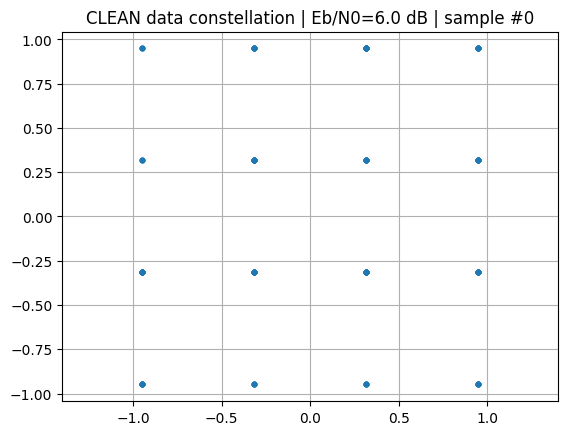

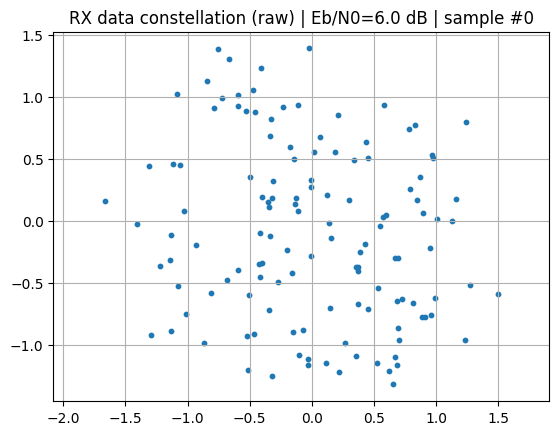

Eb/N0=  0.0 dB | preBER=2.503e-01 | postBER=2.682e-01 | BLER=1.000e+00
Eb/N0=  1.0 dB | preBER=2.250e-01 | postBER=2.490e-01 | BLER=1.000e+00
Eb/N0=  2.0 dB | preBER=1.998e-01 | postBER=2.287e-01 | BLER=1.000e+00
Eb/N0=  3.0 dB | preBER=1.759e-01 | postBER=1.995e-01 | BLER=9.910e-01
Eb/N0=  4.0 dB | preBER=1.531e-01 | postBER=1.396e-01 | BLER=8.273e-01
Eb/N0=  5.0 dB | preBER=1.319e-01 | postBER=7.766e-02 | BLER=4.880e-01
Eb/N0=  6.0 dB | preBER=1.104e-01 | postBER=4.079e-02 | BLER=2.513e-01
Eb/N0=  7.0 dB | preBER=9.130e-02 | postBER=2.144e-02 | BLER=1.403e-01
Eb/N0=  8.0 dB | preBER=7.318e-02 | postBER=1.016e-02 | BLER=7.233e-02
Eb/N0=  9.0 dB | preBER=5.782e-02 | postBER=4.852e-03 | BLER=3.333e-02
Eb/N0= 10.0 dB | preBER=4.539e-02 | postBER=2.003e-03 | BLER=1.433e-02
Eb/N0= 11.0 dB | preBER=3.388e-02 | postBER=8.789e-04 | BLER=7.000e-03
Eb/N0= 12.0 dB | preBER=2.359e-02 | postBER=1.992e-04 | BLER=2.000e-03
Eb/N0= 13.0 dB | preBER=1.704e-02 | postBER=7.943e-05 | BLER=1.000e-03


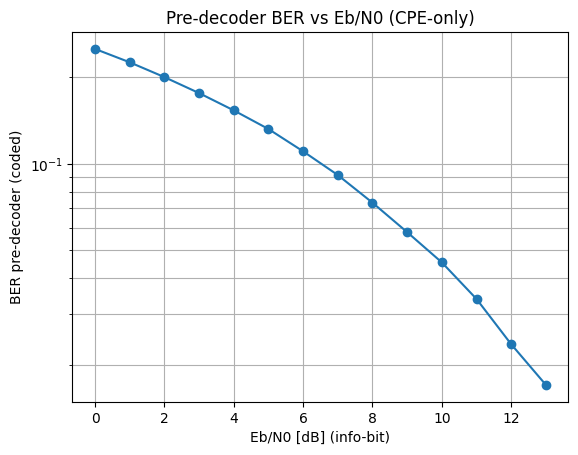

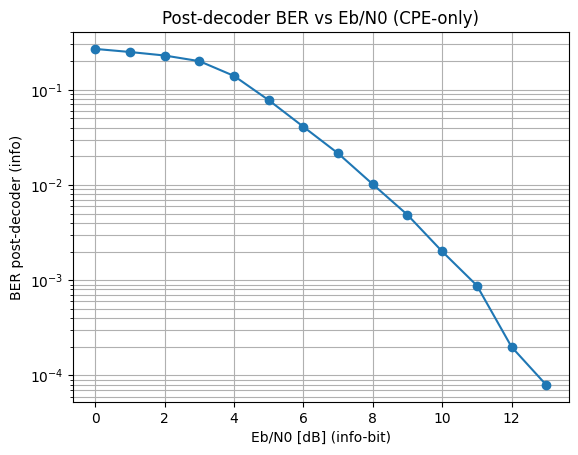

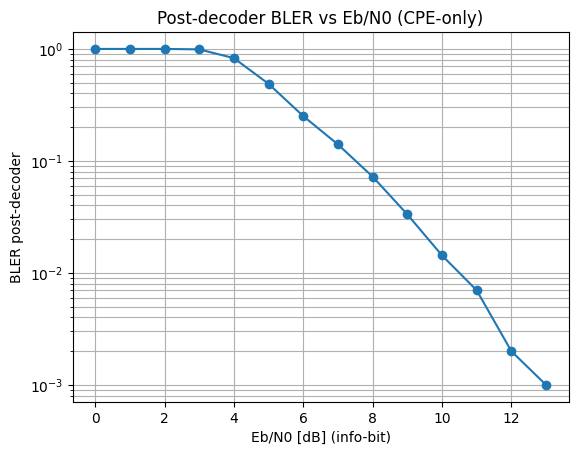

---- PER-SAMPLE REPORT ----
RX:

Sample #0
  Eb/N0 (info-bit) :   8.00 dB
  no (complex var) : 7.578e-02
  phi0 true        : -1.479 rad
  CFO true         : +0.00010 cy/sym  -> Δphi/sym=+0.0006 rad
  PRE  coded BER   : 3.906e-02   (err=20/512)
  POST info  BER   : 0.000e+00  BLER=0 (err=0/256)

Sample #1
  Eb/N0 (info-bit) :   8.00 dB
  no (complex var) : 8.667e-02
  phi0 true        : +0.619 rad
  CFO true         : +0.00016 cy/sym  -> Δphi/sym=+0.0010 rad
  PRE  coded BER   : 1.035e-01   (err=53/512)
  POST info  BER   : 0.000e+00  BLER=0 (err=0/256)

Sample #2
  Eb/N0 (info-bit) :   8.00 dB
  no (complex var) : 8.073e-02
  phi0 true        : -1.283 rad
  CFO true         : -0.00003 cy/sym  -> Δphi/sym=-0.0002 rad
  PRE  coded BER   : 4.688e-02   (err=24/512)
  POST info  BER   : 0.000e+00  BLER=0 (err=0/256)

Sample #3
  Eb/N0 (info-bit) :   8.00 dB
  no (complex var) : 8.568e-02
  phi0 true        : -2.627 rad
  CFO true         : +0.00000 cy/sym  -> Δphi/sym=+0.0000 rad
  PRE  co

In [73]:
# =================
# Main
# =================
if __name__ == "__main__":
    print("Sionna version:", getattr(sionna, "__version__", "unknown"))

    cfg = SimConfig(
        num_examples=4000,
        seq_length=128,
        bits_per_symbol=4,
        k=256,
        pilot_len=8,
        demap_method="app",
        dec_num_iter=15,
        cn_update="minsum",
        seed=46,
        channels_last=True,
        cfo_norm_min=-0.0002,
        cfo_norm_max=+0.0002,
        ebn0_db_min=0.0,
        ebn0_db_max=14.0,
    )

    # 1) Offline dataset generation
    ds = generate_dataset_offline(cfg)
    print("Dataset keys:", list(ds.keys()))
    print("rx_iq_full:", ds["rx_iq_full"].shape, "tx_iq_full:", ds["tx_iq_full"].shape)
    print("rx_iq_data:", ds["rx_iq_data"].shape, "tx_iq_data:", ds["tx_iq_data"].shape)

    # 2) Classical baseline metrics on one realization
    full_tf = simulate_full_frames_tf(cfg)
    rx_cpe = classical_receiver(cfg, full_tf)
    print("\nCPE-only metrics:", rx_cpe["metrics"])

    # 3) Constellation example (clean vs what arrives at RX; optionally corrected)
    plot_constellation_example(cfg, ebn0_db=6.0, idx=0, max_points=256)

    # 4) BER/BLER curves vs Eb/N0 (compare receivers)
    ebn0_grid_db = list(range(0, 14))
    plot_ber_bler_vs_ebn0(cfg, ebn0_grid_db, n_per_point=3000)

    # 5) Per-sample report (optional, helps debugging)
    report_blocks(cfg, num_blocks=10, ebn0_db=8.0)